In [2]:
! pip install uproot

In [1]:
import uproot 
import numpy as np 
import matplotlib.pyplot as plt 


f = uproot.open("data/output/allpix-squared.root")


print("Keys in ROOT file:")
for key in f.keys():
    print(" ", key)

ModuleNotFoundError: No module named 'uproot'

In [3]:
! pip install uproot

In [4]:
import sys
!{sys.executable} -m pip install uproot numpy matplotlib

  Using cached uproot-5.7.3-py3-none-any.whl.metadata (35 kB)
  Using cached awkward-2.9.0-py3-none-any.whl.metadata (7.4 kB)
Using cached uproot-5.7.3-py3-none-any.whl (395 kB)
Using cached awkward-2.9.0-py3-none-any.whl (919 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 654.3/654.3 kB 9.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 10.4 MB/s  0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.2.0
    Uninstalling fsspec-2026.2.0:
      Successfully uninstalled fsspec-2026.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [uproot]━━━━ 6/7 [uproot]awkward]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.7.0 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.3.0 which is incompatible.


In [7]:
import os
print(os.getcwd())

# Find the root file
import subprocess
result = subprocess.run(['find', os.path.expanduser('~'), '-name', '*.root'], 
                      capture_output=True, text=True)
print(result.stdout)

/home/sally/Desktop/itek/senstech-detector-sim/analysis/notebooks
/home/sally/Desktop/itek/senstech-detector-sim/data/modules.root
/home/sally/.config/Code/User/workspaceStorage/6350be9e6a48d362a637aacd8ee39b4d/redhat.java/jdt_ws/.metadata/.plugins/org.eclipse.core.resources/.root
/home/sally/.config/Code/User/workspaceStorage/6350be9e6a48d362a637aacd8ee39b4d/redhat.java/ss_ws/.metadata/.plugins/org.eclipse.core.resources/.root



In [10]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

path = "/home/sally/Desktop/itek/senstech-detector-sim/data/modules.root"
f = uproot.open(path)

print("Keys in ROOT file:")
for key in f.keys():
    print(" ", key)

Keys in ROOT file:
  GeometryBuilderGeant4;1
  DepositionGeant4;1
  ElectricFieldReader;1
  ElectricFieldReader/medipix;1
  GenericPropagation;1
  GenericPropagation/medipix;1
  SimpleTransfer;1
  SimpleTransfer/medipix;1
  DefaultDigitizer;1
  DefaultDigitizer/medipix;1
  DetectorHistogrammer;1
  DetectorHistogrammer/medipix;1
  DetectorHistogrammer/medipix/event_size_pixels;1
  DetectorHistogrammer/medipix/event_size_clusters;1
  DetectorHistogrammer/medipix/hit_map;1
  DetectorHistogrammer/medipix/hit_map_global;1
  DetectorHistogrammer/medipix/hit_map_global_mc;1
  DetectorHistogrammer/medipix/hit_map_local;1
  DetectorHistogrammer/medipix/hit_map_local_mc;1
  DetectorHistogrammer/medipix/cluster_size;1
  DetectorHistogrammer/medipix/cluster_size/cluster_size;1
  DetectorHistogrammer/medipix/cluster_size/cluster_size_x;1
  DetectorHistogrammer/medipix/cluster_size/cluster_size_y;1
  DetectorHistogrammer/medipix/cluster_size/cluster_map;1
  DetectorHistogrammer/medipix/cluster_size/

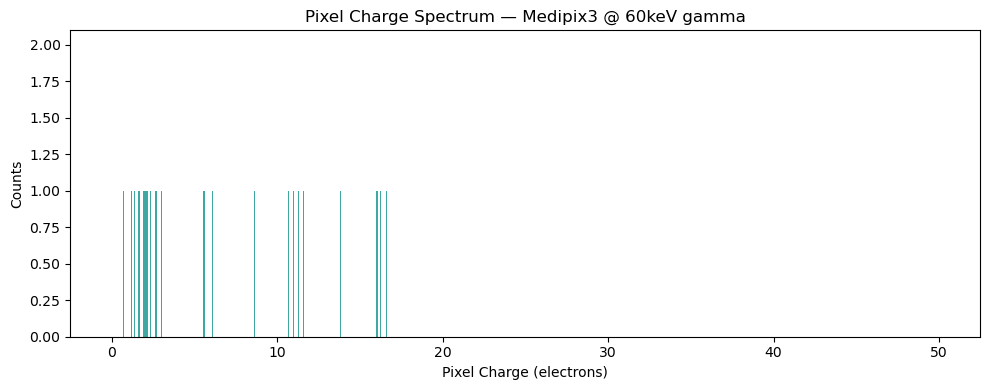

Total pixel hits: 33


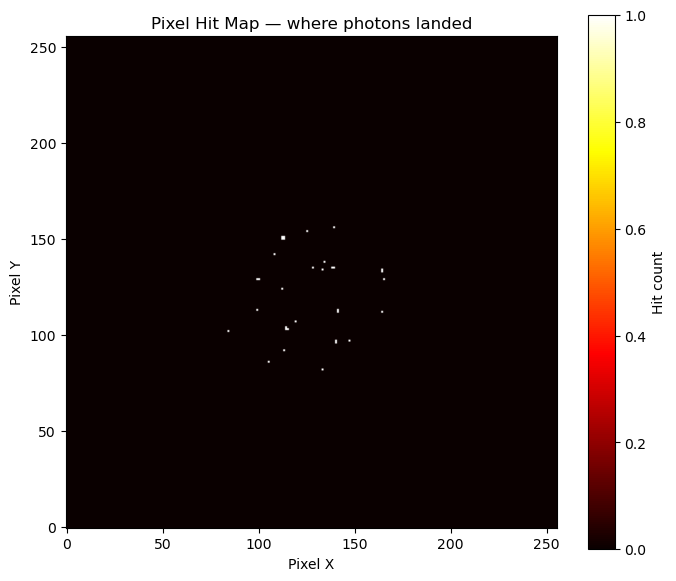

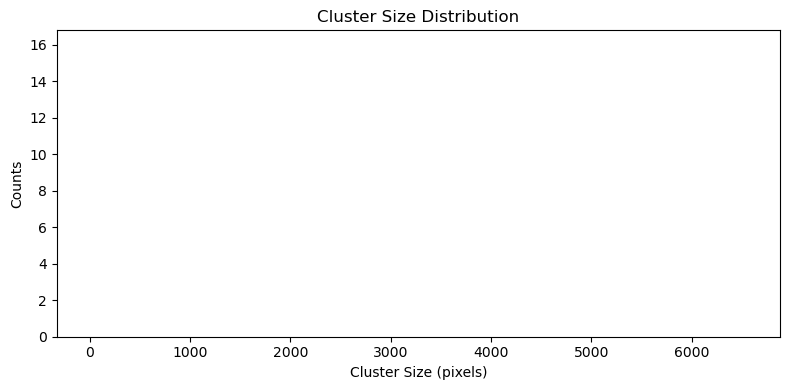


── Simulation Summary ──────────────────────────
Pixel hits detected:     33
Mean pixel charge:       6 electrons
Most common cluster size: 0 pixels
────────────────────────────────────────────────


In [11]:
# ── 1. Pixel charge spectrum ──────────────────────────────────────────────
pixel_charge = f["DetectorHistogrammer/medipix/charge/pixel_charge;1"]
charge_values = pixel_charge.to_numpy()

plt.figure(figsize=(10, 4))
plt.bar(charge_values[1][:-1], charge_values[0], 
        width=np.diff(charge_values[1]), color="#0D9488", alpha=0.8)
plt.xlabel("Pixel Charge (electrons)")
plt.ylabel("Counts")
plt.title("Pixel Charge Spectrum — Medipix3 @ 60keV gamma")
plt.tight_layout()
plt.savefig("charge_spectrum.png", dpi=150)
plt.show()
print(f"Total pixel hits: {charge_values[0].sum():.0f}")

# ── 2. Hit map — which pixels fired ──────────────────────────────────────
hit_map = f["DetectorHistogrammer/medipix/hit_map;1"]
hit_values = hit_map.to_numpy()

plt.figure(figsize=(7, 6))
plt.imshow(hit_values[0], cmap="hot", origin="lower")
plt.colorbar(label="Hit count")
plt.title("Pixel Hit Map — where photons landed")
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")
plt.tight_layout()
plt.savefig("hit_map.png", dpi=150)
plt.show()

# ── 3. Cluster size distribution ─────────────────────────────────────────
cluster_size = f["DetectorHistogrammer/medipix/cluster_size/cluster_size;1"]
cs_values = cluster_size.to_numpy()

plt.figure(figsize=(8, 4))
plt.bar(cs_values[1][:-1], cs_values[0],
        width=np.diff(cs_values[1]), color="#0369A1", alpha=0.8)
plt.xlabel("Cluster Size (pixels)")
plt.ylabel("Counts")
plt.title("Cluster Size Distribution")
plt.tight_layout()
plt.savefig("cluster_size.png", dpi=150)
plt.show()

# ── 4. Summary stats ──────────────────────────────────────────────────────
total_charge = f["DetectorHistogrammer/medipix/charge/total_charge;1"]
tc_values = total_charge.to_numpy()

print("\n── Simulation Summary ──────────────────────────")
print(f"Pixel hits detected:     {charge_values[0].sum():.0f}")
print(f"Mean pixel charge:       {np.average(charge_values[1][:-1], weights=charge_values[0]+1e-9):.0f} electrons")
print(f"Most common cluster size: {cs_values[1][np.argmax(cs_values[0])]:.0f} pixels")
print("────────────────────────────────────────────────")

In [12]:
import uproot

f = uproot.open("/home/sally/Desktop/itek/senstech-detector-sim/data/modules.root")
for key in f.keys():
    print(key)

GeometryBuilderGeant4;1
DepositionGeant4;1
ElectricFieldReader;1
ElectricFieldReader/cdte_detector;1
GenericPropagation;1
GenericPropagation/cdte_detector;1
SimpleTransfer;1
SimpleTransfer/cdte_detector;1
DefaultDigitizer;1
DefaultDigitizer/cdte_detector;1
DetectorHistogrammer;1
DetectorHistogrammer/cdte_detector;1
DetectorHistogrammer/cdte_detector/event_size_pixels;1
DetectorHistogrammer/cdte_detector/event_size_clusters;1
DetectorHistogrammer/cdte_detector/hit_map;1
DetectorHistogrammer/cdte_detector/hit_map_global;1
DetectorHistogrammer/cdte_detector/hit_map_global_mc;1
DetectorHistogrammer/cdte_detector/hit_map_local;1
DetectorHistogrammer/cdte_detector/hit_map_local_mc;1
DetectorHistogrammer/cdte_detector/cluster_size;1
DetectorHistogrammer/cdte_detector/cluster_size/cluster_size;1
DetectorHistogrammer/cdte_detector/cluster_size/cluster_size_x;1
DetectorHistogrammer/cdte_detector/cluster_size/cluster_size_y;1
DetectorHistogrammer/cdte_detector/cluster_size/cluster_map;1
DetectorH